# Benchmark Lag 56 - Modèle de Référence Simple

## Objectif :
Créer un modèle de référence (benchmark) simple qui prédit les ventes en utilisant uniquement le lag de 56 jours (8 semaines).

**Hypothèse** : La meilleure prédiction pour les ventes d'aujourd'hui est celle d'il y a exactement 56 jours (même jour de la semaine, 8 semaines avant).

Ce benchmark nous permettra de comparer la performance de modèles plus complexes (XGBoost, LSTM, etc.).

In [1]:
# 1. IMPORTS ET CONFIGURATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ajouter le chemin pour importer depuis src
sys.path.append('..')
from src.evaluation import evaluate_model

# Configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Paramètres
TEST_DAYS = 56  # 8 semaines
LAG_DAYS = 56   # Lag de référence

print("📦 Configuration terminée")
print(f"🎯 Benchmark: Prédiction = Ventes d'il y a {LAG_DAYS} jours")
print(f"📊 Période de test: {TEST_DAYS} jours")

📦 Configuration terminée
🎯 Benchmark: Prédiction = Ventes d'il y a 56 jours
📊 Période de test: 56 jours


In [2]:
# 2. CHARGEMENT DES DONNÉES
print("📂 Chargement des données...")

train = pd.read_parquet('../data/train_sales_data.parquet')
test = pd.read_parquet('../data/test_sales_data.parquet')

print(f"Train initial: {train.shape}")
print(f"Test initial: {test.shape}")

# Supprimer 2013 comme dans les autres notebooks
def delete_2013(df):
    return df[df['year'] != 2013]

train = delete_2013(train)
test = delete_2013(test)

print(f"Après suppression 2013:")
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

# Combiner train et test pour avoir toutes les données
all_data = pd.concat([train, test], ignore_index=True)
all_data = all_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

print(f"Données combinées: {all_data.shape}")
print(f"Période: {all_data['date'].min().date()} → {all_data['date'].max().date()}")

📂 Chargement des données...
Train initial: (2901096, 47)
Test initial: (99792, 47)
Après suppression 2013:
Train: (2252448, 47)
Test: (99792, 47)
Données combinées: (2352240, 47)
Période: 2014-01-01 → 2017-08-15


In [3]:
# 3. DÉFINITION PÉRIODE DE TEST (8 SEMAINES = 56 JOURS)
print(f"🎯 Définition période de test: {TEST_DAYS} jours...")

# Toutes les dates disponibles
all_dates = pd.to_datetime(all_data['date']).unique()
all_dates = np.sort(all_dates)

# Derniers 56 jours = période de test
test_start = pd.Timestamp(all_dates[-TEST_DAYS])
test_end = pd.Timestamp(all_dates[-1])

print(f"Période de test: {test_start.date()} au {test_end.date()}")
print(f"Nombre de jours: {(test_end - test_start).days + 1}")

# Split train/test selon les dates
train_data = all_data[all_data['date'] < test_start].copy()
test_data = all_data[all_data['date'] >= test_start].copy()

print(f"\n📊 Répartition finale:")
print(f"Train: {train_data.shape[0]:,} échantillons")
print(f"Test: {test_data.shape[0]:,} échantillons")
print(f"Période train: {train_data['date'].min().date()} → {train_data['date'].max().date()}")
print(f"Période test: {test_data['date'].min().date()} → {test_data['date'].max().date()}")

🎯 Définition période de test: 56 jours...
Période de test: 2017-06-21 au 2017-08-15
Nombre de jours: 56

📊 Répartition finale:
Train: 2,252,448 échantillons
Test: 99,792 échantillons
Période train: 2014-01-01 → 2017-06-20
Période test: 2017-06-21 → 2017-08-15


In [4]:
# 4. CRÉATION DU LAG 56 JOURS
print(f"🔄 Création du lag {LAG_DAYS} jours...")

# Trier les données par magasin, famille et date
all_data_sorted = all_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# Créer le lag 56 pour chaque combinaison store_nbr/family
all_data_sorted['sales_lag_56'] = all_data_sorted.groupby(['store_nbr', 'family'])['sales'].shift(LAG_DAYS)

print(f"✅ Lag {LAG_DAYS} créé")

# Vérifier les valeurs manquantes
missing_lag = all_data_sorted['sales_lag_56'].isna().sum()
print(f"Valeurs manquantes dans le lag: {missing_lag:,} ({missing_lag/len(all_data_sorted)*100:.1f}%)")

# Filtrer les données de test avec le lag disponible
test_data_with_lag = all_data_sorted[
    (all_data_sorted['date'] >= test_start) & 
    (all_data_sorted['sales_lag_56'].notna())
].copy()

print(f"\n📊 Données de test avec lag disponible: {len(test_data_with_lag):,} échantillons")
print(f"Couverture: {len(test_data_with_lag)/len(test_data)*100:.1f}% des données de test")

🔄 Création du lag 56 jours...
✅ Lag 56 créé
Valeurs manquantes dans le lag: 99,792 (4.2%)

📊 Données de test avec lag disponible: 99,792 échantillons
Couverture: 100.0% des données de test


In [5]:
# 5. MODÈLE BENCHMARK LAG 56
print("🎯 Application du modèle benchmark...")

# Le modèle benchmark : prédiction = ventes d'il y a 56 jours
y_true = test_data_with_lag['sales'].values
y_pred_lag56 = test_data_with_lag['sales_lag_56'].values

# Statistiques de base
print(f"\n📊 Statistiques des prédictions:")
print(f"Ventes réelles - Min: {y_true.min():.2f}, Max: {y_true.max():.2f}, Moyenne: {y_true.mean():.2f}")
print(f"Prédictions lag56 - Min: {y_pred_lag56.min():.2f}, Max: {y_pred_lag56.max():.2f}, Moyenne: {y_pred_lag56.mean():.2f}")

# Métriques simples
rmse_simple = np.sqrt(mean_squared_error(y_true, y_pred_lag56))
mae_simple = mean_absolute_error(y_true, y_pred_lag56)

print(f"\n📈 Métriques simples (sans pondération):")
print(f"RMSE: {rmse_simple:.4f}")
print(f"MAE: {mae_simple:.4f}")
print(f"Corrélation: {np.corrcoef(y_true, y_pred_lag56)[0,1]:.4f}")

🎯 Application du modèle benchmark...

📊 Statistiques des prédictions:
Ventes réelles - Min: 0.00, Max: 21180.00, Moyenne: 473.39
Prédictions lag56 - Min: 0.00, Max: 24744.00, Moyenne: 492.15

📈 Métriques simples (sans pondération):
RMSE: 369.3196
MAE: 95.1276
Corrélation: 0.9637


In [6]:
# 6. ÉVALUATION AVEC LA FONCTION DU SRC (PONDÉRÉE)
print("⚖️ Évaluation avec pondération (fonction src.evaluation)...")

# Préparer les variables de pondération
is_store_closed = test_data_with_lag['is_store_closed'].values if 'is_store_closed' in test_data_with_lag.columns else np.zeros(len(y_true))
is_family_unactive = test_data_with_lag['is_family_unactive'].values if 'is_family_unactive' in test_data_with_lag.columns else np.zeros(len(y_true))

print(f"Variables de pondération:")
print(f"is_store_closed disponible: {'is_store_closed' in test_data_with_lag.columns}")
print(f"is_family_unactive disponible: {'is_family_unactive' in test_data_with_lag.columns}")

if 'is_store_closed' in test_data_with_lag.columns:
    print(f"Magasins fermés: {is_store_closed.sum():,} observations ({is_store_closed.mean()*100:.1f}%)")
if 'is_family_unactive' in test_data_with_lag.columns:
    print(f"Familles inactives: {is_family_unactive.sum():,} observations ({is_family_unactive.mean()*100:.1f}%)")

# Évaluation avec pondération
print(f"\n🎯 BENCHMARK LAG {LAG_DAYS} - ÉVALUATION PONDÉRÉE:")
results_benchmark = evaluate_model(y_true, y_pred_lag56, is_store_closed, is_family_unactive)

⚖️ Évaluation avec pondération (fonction src.evaluation)...
Variables de pondération:
is_store_closed disponible: True
is_family_unactive disponible: True
Magasins fermés: 0 observations (0.0%)
Familles inactives: 7,084 observations (7.1%)

🎯 BENCHMARK LAG 56 - ÉVALUATION PONDÉRÉE:
--- Evaluation (sur 92708 points actifs) ---
Weighted MAE   : 102.3452
Weighted RMSE  : 383.1674
Weighted RMSLE : 0.6113


In [7]:
# 7. ANALYSE PAR FAMILLE DE PRODUITS
print("🏪 Analyse de performance par famille de produits...")

# Performance par famille
family_performance = []

for family in test_data_with_lag['family'].unique():
    mask = test_data_with_lag['family'] == family
    
    if mask.sum() > 0:  # S'assurer qu'il y a des données
        y_true_fam = y_true[mask]
        y_pred_fam = y_pred_lag56[mask]
        
        rmse_fam = np.sqrt(mean_squared_error(y_true_fam, y_pred_fam))
        mae_fam = mean_absolute_error(y_true_fam, y_pred_fam)
        corr_fam = np.corrcoef(y_true_fam, y_pred_fam)[0,1] if len(y_true_fam) > 1 else 0
        
        family_performance.append({
            'family': family,
            'n_observations': len(y_true_fam),
            'mean_sales': y_true_fam.mean(),
            'rmse': rmse_fam,
            'mae': mae_fam,
            'correlation': corr_fam
        })

family_df = pd.DataFrame(family_performance).sort_values('rmse')

print(f"\n🏆 Top 10 familles avec la meilleure performance (RMSE bas):")
print(family_df.head(10)[['family', 'rmse', 'mae', 'correlation', 'mean_sales']].round(4))

print(f"\n💥 Top 10 familles avec la pire performance (RMSE élevé):")
print(family_df.tail(10)[['family', 'rmse', 'mae', 'correlation', 'mean_sales']].round(4))

🏪 Analyse de performance par famille de produits...

🏆 Top 10 familles avec la meilleure performance (RMSE bas):
                     family    rmse     mae  correlation  mean_sales
4                     BOOKS  0.3696  0.0916       0.0646      0.0222
1                 BABY CARE  0.8738  0.2894       0.1537      0.1961
17          HOME APPLIANCES  1.2672  0.7249       0.2102      0.3733
14                 HARDWARE  2.1078  1.4170       0.3515      1.4620
23                MAGAZINES  5.2933  3.3677       0.7633      6.2758
2                    BEAUTY  5.4664  3.4587       0.6363      5.9408
0                AUTOMOTIVE  5.5033  3.9944       0.5401      7.2543
26             PET SUPPLIES  6.1680  3.9064       0.8409      8.7073
27  PLAYERS AND ELECTRONICS  7.0286  4.9018       0.8255     11.5132
21                 LINGERIE  7.6936  4.8899       0.4565      6.9170

💥 Top 10 familles avec la pire performance (RMSE élevé):
           family       rmse       mae  correlation   mean_sales
18   

In [8]:
# 8. ANALYSE PAR MAGASIN
print("🏬 Analyse de performance par magasin...")

# Performance par magasin (top 20 magasins avec le plus de données)
store_counts = test_data_with_lag['store_nbr'].value_counts().head(20)
store_performance = []

for store_nbr in store_counts.index:
    mask = test_data_with_lag['store_nbr'] == store_nbr
    
    y_true_store = y_true[mask]
    y_pred_store = y_pred_lag56[mask]
    
    rmse_store = np.sqrt(mean_squared_error(y_true_store, y_pred_store))
    mae_store = mean_absolute_error(y_true_store, y_pred_store)
    corr_store = np.corrcoef(y_true_store, y_pred_store)[0,1] if len(y_true_store) > 1 else 0
    
    store_performance.append({
        'store_nbr': store_nbr,
        'n_observations': len(y_true_store),
        'mean_sales': y_true_store.mean(),
        'rmse': rmse_store,
        'mae': mae_store,
        'correlation': corr_store
    })

store_df = pd.DataFrame(store_performance).sort_values('rmse')

print(f"\n🏆 Top 10 magasins avec la meilleure performance (RMSE bas):")
print(store_df.head(10)[['store_nbr', 'rmse', 'mae', 'correlation', 'mean_sales']].round(4))

print(f"\n💥 Top 10 magasins avec la pire performance (RMSE élevé):")
print(store_df.tail(10)[['store_nbr', 'rmse', 'mae', 'correlation', 'mean_sales']].round(4))

🏬 Analyse de performance par magasin...

🏆 Top 10 magasins avec la meilleure performance (RMSE bas):
    store_nbr      rmse      mae  correlation  mean_sales
7          35  136.4761  45.0469       0.9484  161.093399
6          34  169.8298  56.8565       0.9781  322.539093
0           1  173.8386  54.0822       0.9728  312.306885
9          37  208.2202  70.1246       0.9754  410.043793
14          2  208.3797  74.1842       0.9813  445.208313
13         42  237.8244  77.3284       0.9667  385.640015
8          36  251.4991  78.7460       0.9593  356.798492
5          33  254.8082  66.0857       0.9356  303.601807
15         43  334.9026  99.8442       0.9693  482.416901
1          41  366.3834  97.4352       0.9288  408.579102

💥 Top 10 magasins avec la pire performance (RMSE élevé):
    store_nbr      rmse       mae  correlation   mean_sales
2          30  373.2577   76.8104       0.7645   203.150406
3          31  385.0789   91.8279       0.9310   428.444214
12         40  417.9647

📊 Génération des visualisations...


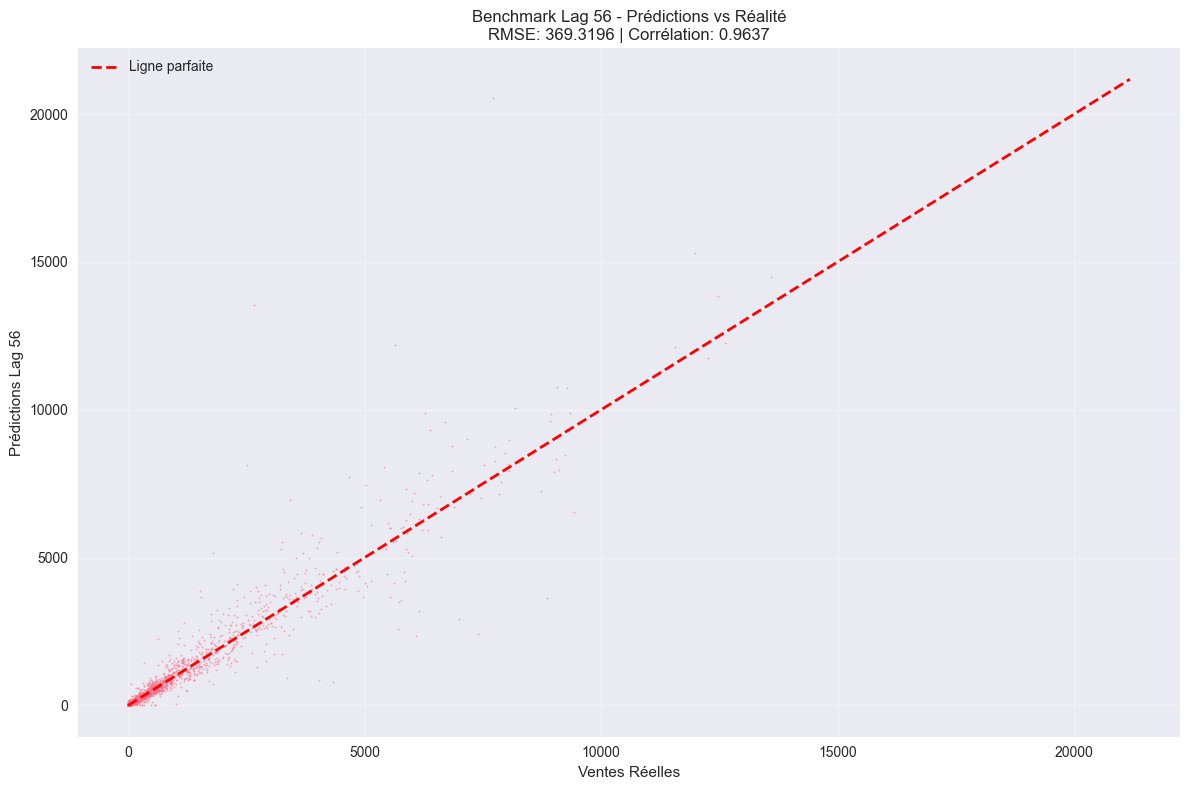

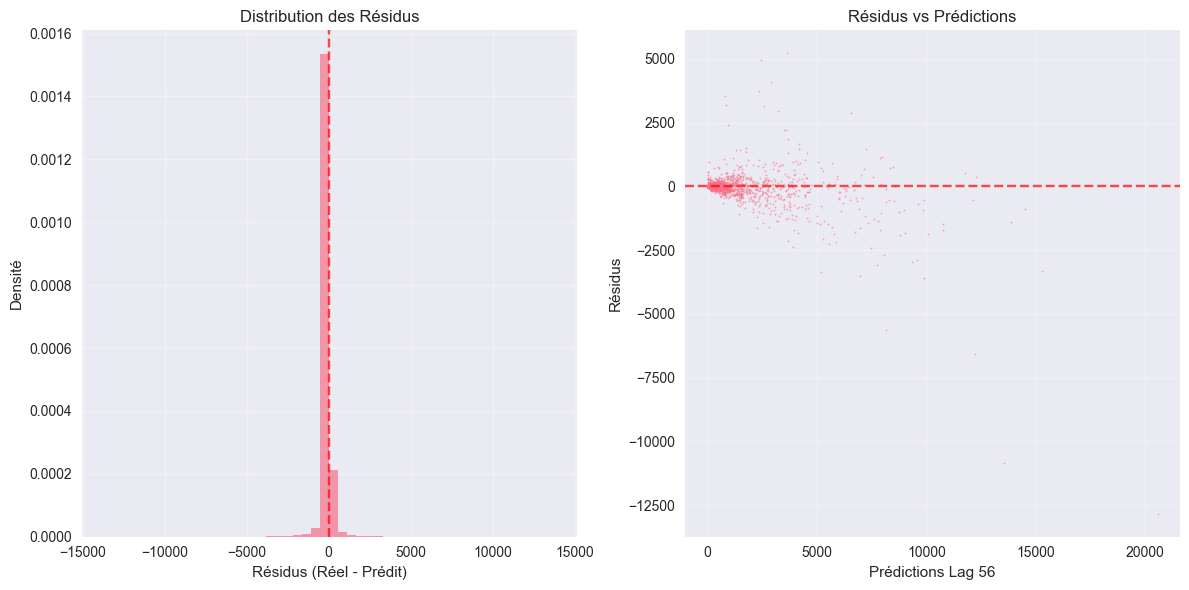

✅ Visualisations générées


In [9]:
# 9. VISUALISATIONS
print("📊 Génération des visualisations...")

# 1. Scatter plot global
plt.figure(figsize=(12, 8))

# Échantillonner pour la visualisation
sample_size = min(5000, len(y_true))
sample_idx = np.random.choice(len(y_true), size=sample_size, replace=False)

plt.scatter(y_true[sample_idx], y_pred_lag56[sample_idx], alpha=0.5, s=1)
plt.plot([0, y_true.max()], [0, y_true.max()], 'r--', lw=2, label='Ligne parfaite')
plt.xlabel('Ventes Réelles')
plt.ylabel(f'Prédictions Lag {LAG_DAYS}')
plt.title(f'Benchmark Lag {LAG_DAYS} - Prédictions vs Réalité\nRMSE: {rmse_simple:.4f} | Corrélation: {np.corrcoef(y_true, y_pred_lag56)[0,1]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Distribution des résidus
residuals = y_true - y_pred_lag56

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, alpha=0.7, density=True)
plt.xlabel('Résidus (Réel - Prédit)')
plt.ylabel('Densité')
plt.title('Distribution des Résidus')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_pred_lag56[sample_idx], residuals[sample_idx], alpha=0.5, s=1)
plt.xlabel(f'Prédictions Lag {LAG_DAYS}')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")

📅 Analyse temporelle des performances...

📊 Performance par semaine:
   week  n_observations  actual_sum  predicted_sum  actual_mean  \
0     1           12474   5630542.5      6527258.0   451.380005   
1     2           12474   6426393.5      6180617.0   515.179993   
2     3           12474   5984240.0      5811581.0   479.739990   
3     4           12474   5762281.0      5983364.0   461.940002   
4     5           12474   5726022.0      5864199.0   459.040009   
5     6           12474   6266050.5      6814233.0   502.329987   
6     7           12474   6051040.5      6010365.0   485.089996   
7     8           12474   5393755.0      5920761.5   432.399994   

   predicted_mean    rmse     mae  
0      523.270020  527.40  118.83  
1      495.480011  336.94   93.76  
2      465.899994  305.71   84.94  
3      479.670013  306.93   73.99  
4      470.109985  293.18   81.62  
5      546.270020  428.56  119.26  
6      481.829987  306.06   85.52  
7      474.649994  385.43  103.12  


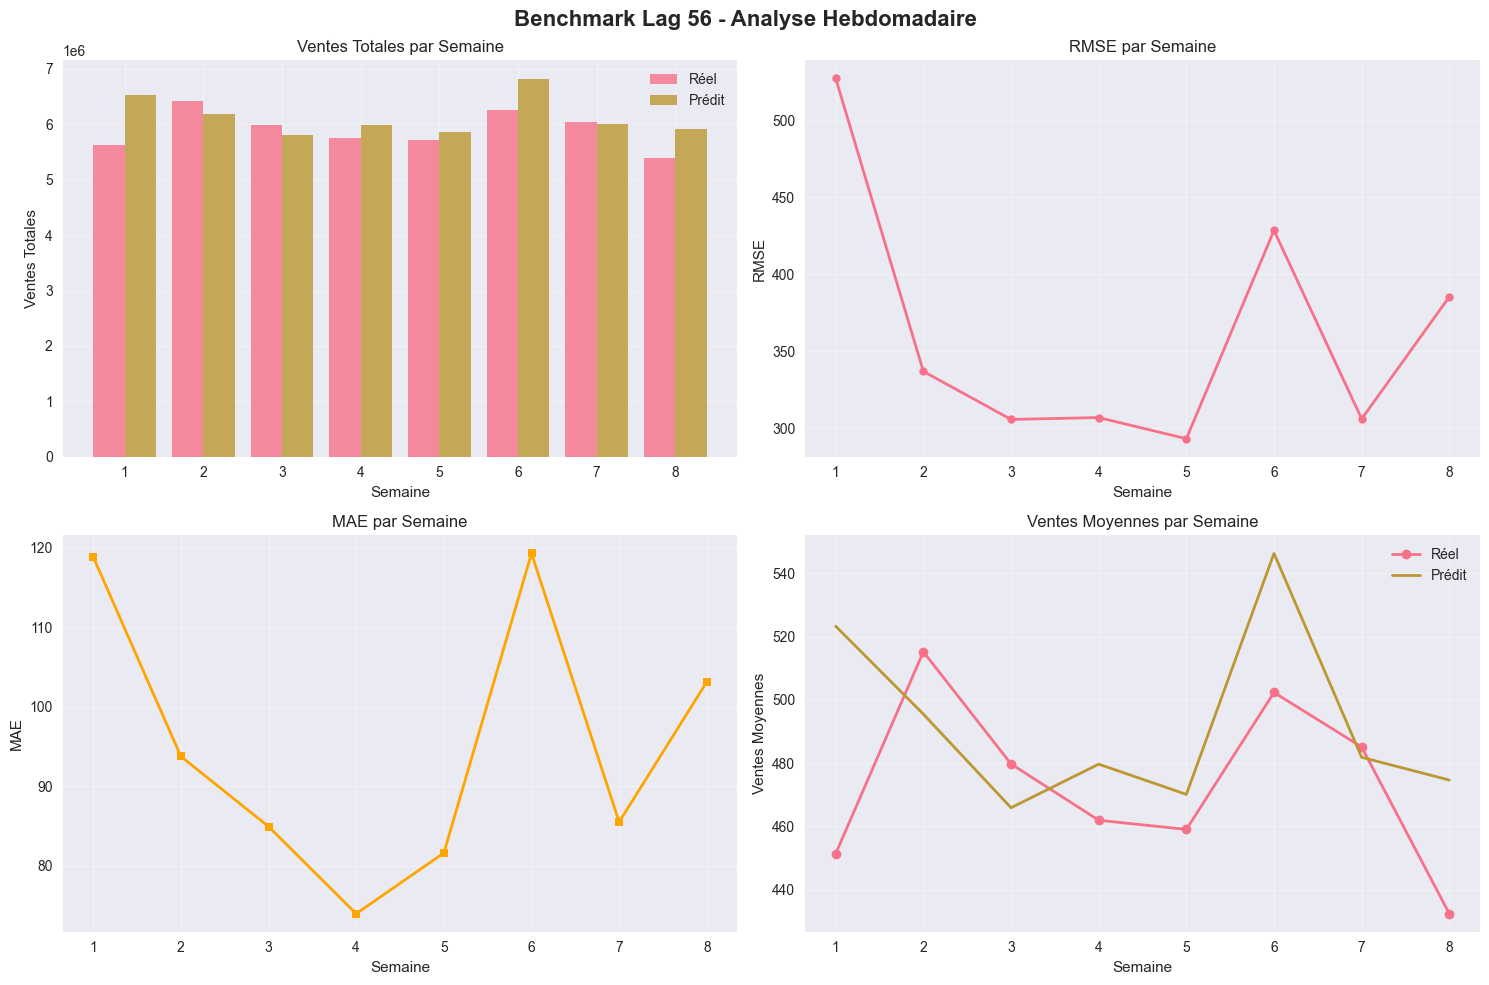

✅ Analyse temporelle terminée


In [11]:
# 10. ANALYSE TEMPORELLE
print("📅 Analyse temporelle des performances...")

# Ajouter le numéro de semaine
test_data_with_lag['week'] = ((test_data_with_lag['date'] - test_start).dt.days // 7) + 1

# Performance par semaine
weekly_performance = []
for week in sorted(test_data_with_lag['week'].unique()):
    mask = test_data_with_lag['week'] == week
    
    y_true_week = y_true[mask]
    y_pred_week = y_pred_lag56[mask]
    
    if len(y_true_week) > 0:
        rmse_week = np.sqrt(mean_squared_error(y_true_week, y_pred_week))
        mae_week = mean_absolute_error(y_true_week, y_pred_week)
        
        weekly_performance.append({
            'week': week,
            'n_observations': len(y_true_week),
            'actual_sum': y_true_week.sum(),
            'predicted_sum': y_pred_week.sum(),
            'actual_mean': y_true_week.mean(),
            'predicted_mean': y_pred_week.mean(),
            'rmse': rmse_week,
            'mae': mae_week
        })

weekly_df = pd.DataFrame(weekly_performance)

print("\n📊 Performance par semaine:")
print(weekly_df.round(2))

# Visualisation hebdomadaire
if len(weekly_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Benchmark Lag {LAG_DAYS} - Analyse Hebdomadaire', fontsize=16, fontweight='bold')
    
    weeks = weekly_df['week']
    
    # 1. Ventes totales
    axes[0,0].bar(weeks - 0.2, weekly_df['actual_sum'], width=0.4, label='Réel', alpha=0.8)
    axes[0,0].bar(weeks + 0.2, weekly_df['predicted_sum'], width=0.4, label='Prédit', alpha=0.8)
    axes[0,0].set_title('Ventes Totales par Semaine')
    axes[0,0].set_xlabel('Semaine')
    axes[0,0].set_ylabel('Ventes Totales')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. RMSE par semaine
    axes[0,1].plot(weeks, weekly_df['rmse'], marker='o', linewidth=2, markersize=6)
    axes[0,1].set_title('RMSE par Semaine')
    axes[0,1].set_xlabel('Semaine')
    axes[0,1].set_ylabel('RMSE')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. MAE par semaine
    axes[1,0].plot(weeks, weekly_df['mae'], marker='s', linewidth=2, markersize=6, color='orange')
    axes[1,0].set_title('MAE par Semaine')
    axes[1,0].set_xlabel('Semaine')
    axes[1,0].set_ylabel('MAE')
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Ventes moyennes
    axes[1,1].plot(weeks, weekly_df['actual_mean'], marker='o', label='Réel', linewidth=2)
    axes[1,1].plot(weeks, weekly_df['predicted_mean'], marker='x', label='Prédit', linewidth=2)
    axes[1,1].set_title('Ventes Moyennes par Semaine')
    axes[1,1].set_xlabel('Semaine')
    axes[1,1].set_ylabel('Ventes Moyennes')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ Analyse temporelle terminée")

In [12]:
# 11. RÉSUMÉ FINAL
print("\n" + "="*80)
print("🎉 RÉSUMÉ FINAL - BENCHMARK LAG 56")
print("="*80)

print(f"\n📊 MODÈLE:")
print(f"   • Type: Benchmark simple")
print(f"   • Prédiction: Ventes d'il y a {LAG_DAYS} jours")
print(f"   • Hypothèse: Saisonnalité hebdomadaire parfaite")

print(f"\n📈 DONNÉES:")
print(f"   • Période de test: {test_start.date()} → {test_end.date()} ({TEST_DAYS} jours)")
print(f"   • Observations avec lag disponible: {len(test_data_with_lag):,}")
print(f"   • Couverture: {len(test_data_with_lag)/len(test_data)*100:.1f}% des données de test")

print(f"\n🎯 PERFORMANCE GLOBALE:")
print(f"   • RMSE simple: {rmse_simple:.4f}")
print(f"   • MAE simple: {mae_simple:.4f}")
print(f"   • Corrélation: {np.corrcoef(y_true, y_pred_lag56)[0,1]:.4f}")

print(f"\n⚖️ PERFORMANCE PONDÉRÉE (src.evaluation):")
print(f"   • Weighted RMSE: {results_benchmark['rmse']:.4f}")
print(f"   • Weighted MAE: {results_benchmark['mae']:.4f}")
print(f"   • Weighted RMSLE: {results_benchmark['rmsle']:.4f}")

if len(weekly_df) > 0:
    print(f"\n📅 PERFORMANCE HEBDOMADAIRE:")
    for _, row in weekly_df.iterrows():
        print(f"   • Semaine {int(row['week'])}: RMSE = {row['rmse']:.4f}, MAE = {row['mae']:.4f}")

print(f"\n🏆 MEILLEURES FAMILLES (RMSE):")
for _, row in family_df.head(3).iterrows():
    print(f"   • {row['family']}: RMSE = {row['rmse']:.4f}")

print(f"\n💡 UTILISATION:")
print(f"   • Ce benchmark sert de référence pour évaluer d'autres modèles")
print(f"   • Un modèle complexe doit battre ces performances pour être utile")
print(f"   • RMSE à battre: {results_benchmark['rmse']:.4f} (pondéré)")

print("\n" + "="*80)
print("✅ BENCHMARK LAG 56 TERMINÉ")
print("🎯 RÉFÉRENCE ÉTABLIE POUR COMPARAISONS FUTURES")
print("="*80)


🎉 RÉSUMÉ FINAL - BENCHMARK LAG 56

📊 MODÈLE:
   • Type: Benchmark simple
   • Prédiction: Ventes d'il y a 56 jours
   • Hypothèse: Saisonnalité hebdomadaire parfaite

📈 DONNÉES:
   • Période de test: 2017-06-21 → 2017-08-15 (56 jours)
   • Observations avec lag disponible: 99,792
   • Couverture: 100.0% des données de test

🎯 PERFORMANCE GLOBALE:
   • RMSE simple: 369.3196
   • MAE simple: 95.1276
   • Corrélation: 0.9637

⚖️ PERFORMANCE PONDÉRÉE (src.evaluation):
   • Weighted RMSE: 383.1674
   • Weighted MAE: 102.3452
   • Weighted RMSLE: 0.6113

📅 PERFORMANCE HEBDOMADAIRE:
   • Semaine 1: RMSE = 527.3971, MAE = 118.8258
   • Semaine 2: RMSE = 336.9355, MAE = 93.7579
   • Semaine 3: RMSE = 305.7081, MAE = 84.9396
   • Semaine 4: RMSE = 306.9287, MAE = 73.9862
   • Semaine 5: RMSE = 293.1755, MAE = 81.6199
   • Semaine 6: RMSE = 428.5584, MAE = 119.2599
   • Semaine 7: RMSE = 306.0567, MAE = 85.5154
   • Semaine 8: RMSE = 385.4286, MAE = 103.1164

🏆 MEILLEURES FAMILLES (RMSE):
   • B